# Titelgenerator voor HBO Kennisbank

## 1. Inleiding

De HBO Kennisbank bevat een grote verzameling afstudeerverslagen en onderzoeksrapporten van Nederlandse hogescholen. Deze documenten bevatten doorgaans een titel en een samenvatting waarin de belangrijkste inhoud van het onderzoek wordt beschreven.

Het handmatig formuleren van een goede titel vereist inzicht in de inhoud van een document en het vermogen om de belangrijkste informatie op een korte en duidelijke manier samen te vatten. Dit maakt titelgeneratie een interessante toepassing van Large Language Models (LLM's).

In dit project wordt onderzocht in hoeverre een taalmodel automatisch academische titels kan genereren op basis van samenvattingen uit de HBO Kennisbank. Hiervoor wordt een complete machine learning pipeline ontwikkeld, bestaande uit dataverzameling, voorbewerking, fine-tuning van een bestaand taalmodel, vergelijking van verschillende generatie-strategieën en toepassing van AI-feedback.

Door verschillende methoden met elkaar te vergelijken wordt inzicht verkregen in de factoren die invloed hebben op de kwaliteit van automatisch gegenereerde titels.

### Onderzoeksvraag

> In hoeverre kan een gefinetunede FLAN-T5 automatisch academische titels genereren voor afstudeerverslagen uit de HBO Kennisbank, en welke invloed hebben verschillende samplingstrategieën en Reinforcement Learning from AI Feedback (RLAIF) op de kwaliteit van de gegenereerde titels?

---

# Inhoudsopgave

1. [Inleiding](#1-inleiding)
2. [Voorbereiding van de omgeving](#2-voorbereiding-van-de-omgeving)
3. [Dataset](#3-dataset)
4. [Verkennen en analyseren van de dataset](#4-visualiseren-en-analyseren)
5. [Voorbewerking en tokenisatie](#5-voorbewerking-van-de-data)
6. [Fine-tuning van FLAN-T5](#6-fine-tuning-van-flan-t5)
7. [Titelgeneratie en samplingstrategieën](#7-titelgeneratie-en-samplingstrategieën)
8. [Reinforcement Learning from AI Feedback (RLAIF)](#8-rlaif-reinforcement-learning-from-ai-feedback)
9. [Vergelijking van alle modellen](#9-vergelijking-van-de-modellen)
10. [Conclusie](#10-conclusie)

## 2. Voorbereiding van de omgeving

Voordat de dataset kan worden verwerkt en het model kan worden getraind, worden de benodigde bibliotheken geïmporteerd en worden de belangrijkste instellingen van het experiment vastgelegd.

Door alle configuraties centraal te definiëren ontstaat een reproduceerbare experimentele omgeving. Dit maakt het mogelijk om resultaten consistent te reproduceren en verschillende experimenten eerlijk met elkaar te vergelijken.

### 2.1 Importeren

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed,
    TrainingArguments,
    Trainer
)
import evaluate
from IPython.display import display
from groq import Groq
import re
import time


c:\Users\verav\GenAI-Portfolio2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 Configuratie van het experiment

In deze stap worden de belangrijkste instellingen van het project vastgelegd.

Hieronder vallen:
- het pad naar de dataset;
- het gekozen basismodel;
- maximale invoer- en uitvoerlengtes;
- de grootte van de trainings- en validatiesets;
- de random seed voor reproduceerbaarheid.

Daarnaast wordt een prompt-prefix gedefinieerd die het model expliciet instrueert om een titel te genereren op basis van een samenvatting.

In [2]:
csv_path = Path(r"hbo_kennisbank_clean.csv")
model_name = "google/flan-t5-small"
output_dir = Path("title_generator_flan_t5_small")
random_state = 42
max_source_length = 256
max_target_length = 32
max_train_examples = 400
max_val_examples = 100

prefix = "Genereer een korte en informatieve titel: "

set_seed(random_state)
output_dir.mkdir(exist_ok=True)


De gekozen configuratie vormt de basis voor alle verdere experimenten in dit notebook.

Er is gekozen voor FLAN-T5 Small omdat dit model relatief lichtgewicht is en binnen de hardware-eisen van de opdracht kan worden gefinetuned. Tegelijkertijd beschikt het model al over sterke taalvaardigheden doordat het vooraf is getraind op grote hoeveelheden tekst en instructies.

De maximale invoerlengte is afgestemd op de lengte van de samenvattingen uit de HBO Kennisbank, terwijl de uitvoerlengte beperkt blijft omdat titels doorgaans kort zijn.

## 3. Dataset

### 3.1 Beschrijving dataset

Voor dit project is gebruikgemaakt van data afkomstig uit de HBO Kennisbank. De HBO Kennisbank bevat afstudeerverslagen, onderzoeken en scripties van verschillende Nederlandse hogescholen. Deze documenten bevatten doorgaans een titel, samenvatting, opleiding, onderwijsinstelling en aanvullende metadata.

Het doel van dit project is het automatisch genereren van titels op basis van samenvattingen van onderzoeksrapporten. Hiervoor zijn de samenvattingen gebruikt als invoer voor het model en de originele titels als gewenste uitvoer.

Deze taak is interessant voor Large Language Models omdat er meerdere correcte titels mogelijk zijn voor dezelfde samenvatting. Hierdoor is het een generatieve taak waarbij zowel inhoudelijke relevantie als taalgebruik belangrijk zijn.

In het andere notebook (hbo_scraper.ipynb) zie je hoe wij prompt engineering hebben gebruikt om de data te webscrapen vanuit de HBO Kennisbank website. 

In deze sectie wordt de verzamelde dataset ingeladen, gecontroleerd en voorbereid voor verdere verwerking. 

### 3.2 Inladen van de dataset

De eerder verzamelde data wordt ingeladen in een Pandas DataFrame. Een DataFrame maakt het mogelijk om de gegevens efficiënt te analyseren, te filteren en voor te bereiden voor machine learning.

In deze stap wordt gecontroleerd of de dataset correct is ingelezen en welke kolommen beschikbaar zijn.

In [3]:
df = pd.read_csv(csv_path)
expected_columns = {"title", "abstract"}
missing_columns = expected_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Ontbrekende kolommen in CSV: {sorted(missing_columns)}")

### 3.3 Opschonen van de dataset

Niet alle records zijn bruikbaar voor training. Daarom worden records verwijderd die geen titel of samenvatting bevatten.

Daarnaast worden dubbele records verwijderd om te voorkomen dat het model dezelfde voorbeelden meerdere keren ziet tijdens de training.

In [4]:
df = df.loc[:, ["abstract", "title"]].dropna().copy()

df["abstract"] = (
    df["abstract"]
    .astype(str)
    .str.strip()
)

df["title"] = (
    df["title"]
    .astype(str)
    .str.strip()
)

df = df[
    (df["abstract"] != "") &
    (df["title"] != "")
]

df = (
    df
    .drop_duplicates(
        subset=["abstract", "title"]
    )
    .reset_index(drop=True)
)

### 3.4 Eerste inspectie van de dataset

Na het opschonen bekijken we de eerste voorbeelden uit de dataset.

Hiermee controleren we of de samenvattingen en titels correct zijn ingelezen en of de dataset geschikt lijkt voor de titelgeneratietaak.

In [5]:
print(f"Aantal bruikbare rijen: {len(df)}")

display(df.head())

Aantal bruikbare rijen: 549


,abstract,title
0,Achtergrond: Het herstel na conservatief behan...,Fysiotherapeutische analyse en conservatieve b...
1,In deze scriptie zijn 144 metalen militaria ui...,Civiel centrum Oppidum Batavorum
2,The escalating plastic waste crisis has increa...,Comparative analysis of fingermark development...
3,Artikel over de rol van passie in de amateurkunst,Passie in de amateurkunst
4,Dit rapport is deel I van twee delen waarin de...,A legal overview on International & European S...


De dataset is succesvol ingelezen. Iedere rij vertegenwoordigt één afstudeeronderzoek uit de HBO Kennisbank.

De verschillende kolommen bevatten onder andere informatie over de titel, samenvatting en metadata van het onderzoek. Voor het genereren van titels zijn voornamelijk de titel en samenvatting relevant.

Door eerst de structuur van de dataset te bekijken kunnen we bepalen welke kolommen nodig zijn voor de verdere verwerking.

## 4 Visualiseren en Analyseren

Voordat het model wordt getraind analyseren we enkele eigenschappen van de dataset.

Deze analyse helpt bij het onderbouwen van keuzes zoals de maximale invoerlengte (`max_source_length`) en maximale uitvoerlengte (`max_target_length`).

Daarnaast geeft het inzicht in de complexiteit van de titelgeneratietaak.

### 4.1 Analyse van abstractlengtes

De lengte van de samenvattingen heeft directe invloed op de keuze van de maximale invoerlengte (`max_source_length`) van het model.

Wanneer de invoerlengte te laag wordt gekozen, bestaat het risico dat belangrijke informatie uit langere samenvattingen wordt afgekapt. Een te hoge invoerlengte leidt daarentegen tot hogere rekentijd en meer geheugengebruik zonder dat dit noodzakelijk extra informatie oplevert.

Om deze afweging te onderbouwen wordt de verdeling van de lengte van de samenvattingen geanalyseerd.

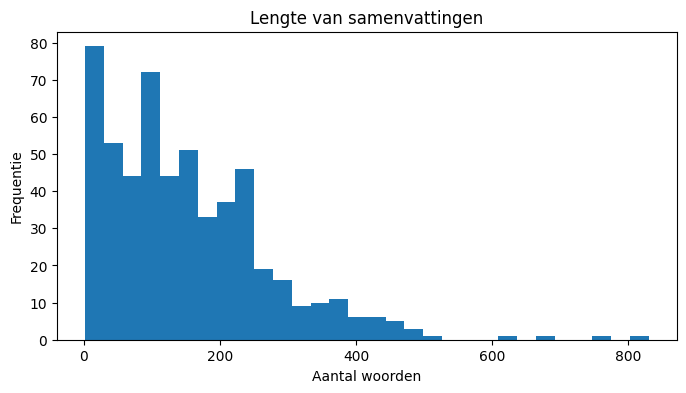

In [6]:
df["abstract_length"] = (
    df["abstract"]
    .str.split()
    .str.len()
)

plt.figure(figsize=(8,4))

plt.hist(
    df["abstract_length"],
    bins=30
)

plt.title("Lengte van samenvattingen")
plt.xlabel("Aantal woorden")
plt.ylabel("Frequentie")

plt.show()

De verdeling laat zien dat de meeste samenvattingen relatief kort zijn. De mediaan bedraagt 128 woorden en 75% van de samenvattingen bevat minder dan 220 woorden.

Daarnaast is zichtbaar dat slechts een klein aantal documenten aanzienlijk langer is, met uitschieters tot ongeveer 830 woorden.

Op basis van deze analyse is gekozen voor een maximale invoerlengte van 256 tokens. Deze waarde is voldoende om het grootste deel van de dataset volledig te verwerken, terwijl de rekentijd en het geheugengebruik beperkt blijven. Alleen een klein aantal uitzonderlijk lange samenvattingen zal gedeeltelijk worden afgekapt.

De keuze voor `max_source_length = 256` is daarmee gebaseerd op de eigenschappen van de dataset en niet willekeurig gekozen.

### 4.2 Lengteverdeling van titels

Naast de lengte van de samenvattingen is ook de lengte van de titels onderzocht.

Deze analyse helpt bij het bepalen van een geschikte maximale uitvoerlengte (`max_target_length`). Omdat het model titels genereert, moet deze waarde voldoende groot zijn om volledige titels te kunnen produceren zonder onnodig veel tokens te genereren.

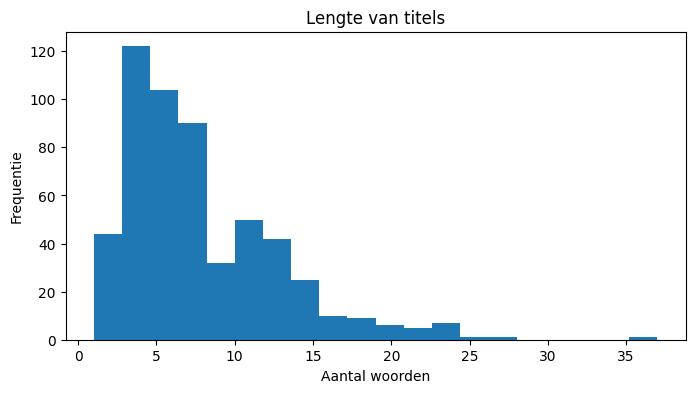

In [7]:
df["title_length"] = (
    df["title"]
    .str.split()
    .str.len()
)

plt.figure(figsize=(8,4))

plt.hist(
    df["title_length"],
    bins=20
)

plt.title("Lengte van titels")
plt.xlabel("Aantal woorden")
plt.ylabel("Frequentie")

plt.show()

De verdeling laat zien dat de meeste titels relatief kort zijn. De mediaan bedraagt 7 woorden en 75% van de titels bevat minder dan 10 woorden.

Slechts een klein aantal titels is langer dan 20 woorden. De langste titel in de dataset bevat 37 woorden.

Op basis van deze resultaten is gekozen voor een maximale uitvoerlengte van 32 tokens. Deze waarde biedt voldoende ruimte voor vrijwel alle titels in de dataset, terwijl tegelijkertijd wordt voorkomen dat het model onnodig lange uitvoer genereert.

De gekozen waarde van `max_target_length = 32` sluit daarmee goed aan bij de waargenomen eigenschappen van de dataset.

### 4.3 Statistieken tabel

De dataset bevat 549 bruikbare documenten afkomstig uit de HBO Kennisbank.

De gemiddelde samenvatting bestaat uit ongeveer 152 woorden, terwijl titels gemiddeld uit ongeveer 8 woorden bestaan. Daarnaast laten zowel de histogrammen als de statistieken zien dat de meeste documenten aanzienlijk korter zijn dan de maximale invoer- en uitvoerlengtes die voor het model zijn gekozen.

Deze analyse bevestigt dat de gekozen configuratie geschikt is voor de dataset:

- `max_source_length = 256`
- `max_target_length = 32`

Hierdoor kunnen de meeste voorbeelden volledig worden verwerkt zonder onnodig hoge rekenkosten. De gekozen instellingen zijn dus gebaseerd op empirische analyse van de dataset en niet uitsluitend op aannames.

In [8]:
df[[
    "abstract_length",
    "title_length"
]].describe()

,abstract_length,title_length
count,549.000000,549.000000
mean,152.211293,7.721311
std,121.221155,5.000066
min,2.000000,1.000000
25%,62.000000,4.000000
50%,128.000000,7.000000
75%,221.000000,10.000000
max,830.000000,37.000000


## 5. Voorbewerking van de data

### 5.1 Train- en validatiesplit

Om het model eerlijk te kunnen evalueren wordt de dataset opgesplitst in een trainingsset en een validatieset.

De trainingsset wordt gebruikt om de modelgewichten aan te passen tijdens het fine-tunen. De validatieset wordt niet gebruikt tijdens de training en dient als onafhankelijke dataset om de prestaties van het model te beoordelen.

Er is gekozen voor een verdeling van 80% training en 20% validatie. Dit is een veelgebruikte verhouding binnen machine learning omdat hiermee voldoende trainingsdata beschikbaar blijft terwijl er tegelijkertijd genoeg voorbeelden overblijven voor evaluatie.

In [9]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=random_state
)

train_df = train_df.head(max_train_examples).reset_index(drop=True)
val_df = val_df.head(max_val_examples).reset_index(drop=True)

Na het splitsen bevat de trainingsset de voorbeelden waarop het model wordt gefinetuned. De validatieset wordt later gebruikt om de prestaties van het model te meten op ongeziene data.

Door gebruik te maken van een vaste random seed blijft deze verdeling reproduceerbaar.

### 5.2 Omzetten naar HuggingFace Dataset

Hoewel de data momenteel is opgeslagen in Pandas DataFrames, werkt de HuggingFace Trainer efficiënter met Dataset-objecten.

Daarom worden de trainings- en validatiesets omgezet naar het Dataset-formaat van HuggingFace. Dit formaat biedt efficiënte ondersteuning voor tokenisatie, batching en training van transformer-modellen.

In [10]:
dataset = DatasetDict(
    {
        "train": Dataset.from_pandas(
            train_df,
            preserve_index=False
        ),
        "validation": Dataset.from_pandas(
            val_df,
            preserve_index=False
        ),
    }
)

Na deze stap zijn de gegevens beschikbaar in een formaat dat direct gebruikt kan worden binnen de HuggingFace ecosystemen voor preprocessing en training.

### 5.3 Initialiseren van de tokenizer

Neurale taalmodellen kunnen niet rechtstreeks met tekst werken. Daarom moet tekst eerst worden omgezet naar tokens.

De tokenizer van FLAN-T5 splitst tekst op in kleinere onderdelen en zet deze vervolgens om naar numerieke token-ID's die door het model kunnen worden verwerkt.

Voor consistentie wordt dezelfde tokenizer gebruikt als het gekozen basismodel.

In [11]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

De tokenizer bepaalt hoe woorden, leestekens en zinsdelen worden omgezet naar tokens. Deze omzetting vormt de basis voor alle verdere modeltraining.

### 5.4 Preprocessing en tokenisatie

Voor iedere samenvatting wordt eerst een instructie toegevoegd:

"Genereer een korte en informatieve titel:"

Omdat FLAN-T5 een instruction-tuned model is, helpt deze expliciete instructie het model om de gewenste taak beter te begrijpen.

Vervolgens worden zowel de samenvattingen als de titels getokenized. Hierbij worden maximale invoer- en uitvoerlengtes toegepast om het geheugengebruik beheersbaar te houden.

In [12]:
def preprocess_batch(batch):
    inputs = [prefix + text for text in batch["abstract"]]
    model_inputs = tokenizer(inputs, max_length=max_source_length, truncation=True)
    labels = tokenizer(text_target=batch["title"], max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

Tijdens de preprocessing worden drie belangrijke onderdelen aangemaakt:

- `input_ids`: de getokeniseerde invoertekst;
- `attention_mask`: geeft aan welke tokens relevant zijn;
- `labels`: de gewenste uitvoer waarop het model wordt getraind.

Deze representaties vormen de uiteindelijke input voor het fine-tunen van FLAN-T5.

### 5.5 Toepassen van preprocessing

De eerder gedefinieerde preprocessingfunctie wordt toegepast op zowel de trainings- als validatieset.

Hierdoor worden alle voorbeelden automatisch omgezet naar het formaat dat nodig is voor modeltraining.

In [13]:
tokenized = dataset.map(
    preprocess_batch,
    batched=True,
    remove_columns=dataset["train"].column_names,
)

Map: 100%|██████████| 100/100 [00:00<00:00, 1071.25 examples/s]


Na deze stap bestaat de dataset niet langer uit ruwe tekst, maar uit token-ID's en labels die direct gebruikt kunnen worden door het FLAN-T5 model tijdens het fine-tunen.

### 5.6 Controle van de trainingsdata

Tot slot worden enkele voorbeelden uit zowel de trainings- als validatieset weergegeven.

Hiermee controleren we of de data correct is verwerkt en of de verdeling van de voorbeelden plausibel lijkt.

In [14]:
display(train_df.head(3))
display(val_df.head(3))

,abstract,title,abstract_length,title_length
0,Dysfagie is een symptoom dat wordt gekenmerkt ...,De TotalCup® in de zorgpraktijk: een kwalitati...,265,15
1,In deze lijst staan alle interventie-ideeën be...,Lijst met interventie-ideeën van mbo-studenten,21,5
2,Met toestemming vqn de uitgever overgenomen ui...,Soenveld_dewit_19122025_essayrobotrechten_nede...,18,1


,abstract,title,abstract_length,title_length
0,Het objectief meten van spierkracht is essenti...,De intra-rater betrouwbaarheid van de citecmot...,137,18
1,Qualitative research in the form of interviews...,Improving the feedback systems at Van der Lind...,57,9
2,El vidrio aislante viejo suele acabar en aplic...,Vidrio Plano 100% Reutilizado: Dando una Segun...,75,13


## 6. Fine-tuning van FLAN-T5

### 6.1 Keuze van het model

Voor dit project is gekozen voor het model `google/flan-t5-small`.

FLAN-T5 is een instruction-tuned variant van T5 (Text-to-Text Transfer Transformer). In tegenstelling tot veel andere taalmodellen zijn vrijwel alle taken binnen FLAN-T5 geformuleerd als een tekst-naar-tekst probleem. Dit sluit goed aan bij de gekozen taak, waarbij een samenvatting als invoer wordt gegeven en een titel als uitvoer moet worden gegenereerd.

De keuze voor FLAN-T5-small is gebaseerd op zowel de eigenschappen van de taak als de technische randvoorwaarden van de opdracht.

#### Geschikt voor sequence-to-sequence taken

Titelgeneratie is een sequence-to-sequence taak: een langere invoertekst moet worden omgezet naar een kortere uitvoertekst. FLAN-T5 is specifiek ontworpen voor dit type toepassingen en wordt veel gebruikt voor taken zoals samenvatten, vertalen, vraagbeantwoording en tekstgeneratie.

Modellen zoals GPT-2 zijn primair ontworpen voor autoregressieve tekstgeneratie en zijn daardoor minder geschikt voor taken waarbij een duidelijke invoer-uitvoerrelatie aanwezig is.

#### Instruction-tuning

Een belangrijk voordeel van FLAN-T5 is dat het model vooraf is getraind op instructies. Hierdoor begrijpt het model opdrachten zoals:

```text
Genereer een korte en informatieve titel:
```

Dit sluit goed aan bij de aanpak in dit project, waarbij aan iedere samenvatting eerst een instructie wordt toegevoegd voordat deze aan het model wordt aangeboden.

#### Rekenkracht en hardwarebeperkingen

Volgens de opdracht moest het volledige trainingsproces kunnen worden uitgevoerd binnen de beschikbare hardware van Google Colab (ongeveer 12 GB RAM).

Grotere modellen zoals:

- FLAN-T5 Base
- FLAN-T5 Large
- Gemma
- Llama

vereisen aanzienlijk meer geheugen en trainingstijd. Hierdoor bestaat het risico dat de training niet binnen de beschikbare middelen of tijdslimieten uitgevoerd kan worden.

FLAN-T5-small biedt een goede balans tussen modelgrootte, trainingssnelheid en prestaties.

#### Vergelijking met alternatieve modellen

| Model | Voordelen | Nadelen |
|---------|---------|---------|
| GPT-2 | Goed voor vrije tekstgeneratie | Minder geschikt voor sequence-to-sequence taken |
| BART | Sterk voor samenvatting en generatie | Groter model en hogere geheugeneisen |
| FLAN-T5 Base/Large | Mogelijk hogere prestaties | Niet efficiënt binnen de beschikbare hardware |
| FLAN-T5 Small | Instruction-tuned, geschikt voor seq2seq en efficiënt te trainen | Lagere maximale prestaties dan grotere varianten |

Op basis van deze afweging is gekozen voor **FLAN-T5-small**. Dit model sluit goed aan bij de titelgeneratietaak en voldoet tegelijkertijd aan de technische randvoorwaarden van de opdracht.

### 6.2 Evaluatie van het basismodel

Voordat het model wordt gefinetuned evalueren we eerst de prestaties van het originele FLAN-T5 model.

Hiermee creëren we een baseline waarmee later kan worden vastgesteld of fine-tuning daadwerkelijk heeft geleid tot betere prestaties.

De evaluatie wordt uitgevoerd op de validatieset met behulp van dezelfde ROUGE-metrieken die later ook voor het gefinetunede model worden gebruikt.

In [15]:
rouge = evaluate.load("rouge")
baseline_model = AutoModelForSeq2SeqLM.from_pretrained(
    model_name
)

baseline_predictions = []
baseline_references = []

for _, row in val_df.iterrows():

    prompt = prefix + row["abstract"]

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=max_source_length
    )

    outputs = baseline_model.generate(
        **inputs,
        max_new_tokens=max_target_length,
        num_beams=4
    )

    prediction = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    baseline_predictions.append(prediction)
    baseline_references.append(row["title"])

baseline_scores = rouge.compute(
    predictions=baseline_predictions,
    references=baseline_references,
    use_stemmer=True
)

print("Baseline ROUGE scores:")
print(baseline_scores)

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 2015.65it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Baseline ROUGE scores:
{'rouge1': np.float64(0.13912309487932717), 'rouge2': np.float64(0.04684875916366475), 'rougeL': np.float64(0.11830344782889993), 'rougeLsum': np.float64(0.12056376223217835)}


De bovenstaande scores geven de prestaties van het oorspronkelijke FLAN-T5 model weer zonder aanvullende training op de HBO Kennisbank dataset.

Deze resultaten worden later vergeleken met de prestaties van het gefinetunede model. Wanneer de ROUGE-scores na fine-tuning hoger zijn, betekent dit dat het model heeft geleerd van de trainingsvoorbeelden en beter in staat is om relevante titels te genereren.

De baseline vormt daarmee een belangrijk referentiepunt voor het beoordelen van het effect van fine-tuning.

### 6.3 Voorbereiding van de training

Voor het fine-tunen worden een data collator, evaluatiemetriek en trainingsinstellingen geconfigureerd.

De data collator zorgt ervoor dat batches automatisch worden voorbereid voor training. Daarnaast wordt ROUGE gebruikt om tijdens de training de kwaliteit van de gegenereerde titels te meten.

In [16]:
# 4. Model fine-tunen en evalueren
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)
rouge = evaluate.load("rouge")


def compute_metrics(eval_preds):
    import numpy as np

    predictions, labels = eval_preds
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # Convert tensors to numpy
    try:
        if hasattr(predictions, "cpu"):
            predictions = predictions.cpu().numpy()
    except Exception:
        pass
    try:
        if hasattr(labels, "cpu"):
            labels = labels.cpu().numpy()
    except Exception:
        pass

    # Replace negative values (including -100) with pad token id for safe decoding
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    if predictions is not None:
        predictions = np.where(predictions < 0, pad_id, predictions)
    if labels is not None:
        labels = np.where(labels < 0, pad_id, labels)

    # Ensure integer dtype for tokenizer
    predictions = predictions.astype(np.int64)
    if labels is not None:
        labels = labels.astype(np.int64)

    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = (
        tokenizer.batch_decode(labels, skip_special_tokens=True) if labels is not None else [""] * len(decoded_preds)
    )

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [lab.strip() for lab in decoded_labels]

    scores = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)
    return {metric: round(value, 4) for metric, value in scores.items()}

Loading weights: 100%|██████████| 190/190 [00:00<00:00, 4033.88it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


### 6.4 Trainingsinstellingen

Voor het fine-tunen zijn verschillende hyperparameters gekozen.

#### Learning rate (3e-4)

De learning rate bepaalt hoe sterk de modelgewichten tijdens iedere update worden aangepast. Een relatief lage waarde is gekozen om stabiel verder te trainen op een reeds bestaand model.

#### Batch size (4)

De batch size bepaalt hoeveel voorbeelden tegelijk worden verwerkt. Door beperkte hardwarecapaciteit is gekozen voor een kleine batch size.

#### Epochs (2)

Omdat de dataset relatief klein is, bestaat het risico op overfitting. Daarom is gekozen voor twee trainingsrondes over de dataset.

#### Beam Search (4)

Tijdens generatie wordt beam search gebruikt om meerdere mogelijke uitvoerreeksen tegelijk te onderzoeken. Dit leidt doorgaans tot stabielere en kwalitatief betere titels.

In [17]:
training_args = Seq2SeqTrainingArguments(
    output_dir=str(output_dir),
    learning_rate=3e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    generation_num_beams=4,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

### 6.5 Fine-tunen van het model

Tijdens het fine-tunen worden de gewichten van FLAN-T5 aangepast aan de titelgeneratietaak.

Het model leert hierbij de relatie tussen samenvattingen en titels uit de HBO Kennisbank dataset.

Door deze aanvullende training kan het model zich beter aanpassen aan de stijl en structuur van academische titels.

In [18]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

### 6.6 Uitvoeren van de training

Na het configureren van het trainingsproces wordt het model gefinetuned op de trainingsset.

Na iedere epoch wordt het model geëvalueerd op de validatieset. De versie met de hoogste ROUGE-L score wordt automatisch opgeslagen.

In [19]:
# Veiligheids-flag om training expliciet te starten
run_training = False # weer terug naar True veranderen

# Training
if run_training:
    trainer.train()
    eval_results = trainer.evaluate()
    print(eval_results)
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
else:
    print("Training is uitgeschakeld. Zet `run_training = True` in de configuratiecel om te starten.")


Training is uitgeschakeld. Zet `run_training = True` in de configuratiecel om te starten.


### 6.7 Effect van fine-tuning

Om te bepalen of de aanvullende training daadwerkelijk heeft geleid tot betere prestaties, worden de resultaten van het oorspronkelijke FLAN-T5 model vergeleken met de resultaten van het gefinetunede model.

Beide modellen worden geëvalueerd op dezelfde validatieset met behulp van de ROUGE-metriek. Hierdoor kan objectief worden vastgesteld of het model heeft geleerd van de HBO Kennisbank dataset.

In [20]:
# Evaluatie van het gefinetunede model
finetuned_predictions = []
finetuned_references = []

for _, row in val_df.iterrows():

    prompt = prefix + row["abstract"]

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        #max_length=max_source_length
    ) 

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_target_length,
        num_beams=4
    )

    prediction = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    finetuned_predictions.append(prediction)
    finetuned_references.append(row["title"])

finetuned_scores = rouge.compute(
    predictions=finetuned_predictions,
    references=finetuned_references,
    use_stemmer=True
)

print("Fine-tuned ROUGE scores:")
print(finetuned_scores)

Fine-tuned ROUGE scores:
{'rouge1': np.float64(0.1444717662275185), 'rouge2': np.float64(0.04121315019224975), 'rougeL': np.float64(0.12269174027077531), 'rougeLsum': np.float64(0.12381467663447479)}


#### Vergelijkingstabel

In [21]:
comparison_df = pd.DataFrame({

    "Model": [
        "Baseline FLAN-T5",
        "Fine-tuned FLAN-T5"
    ],

    "ROUGE-1": [
        baseline_scores["rouge1"],
        finetuned_scores["rouge1"]
    ],

    "ROUGE-2": [
        baseline_scores["rouge2"],
        finetuned_scores["rouge2"]
    ],

    "ROUGE-L": [
        baseline_scores["rougeL"],
        finetuned_scores["rougeL"]
    ]
})

display(comparison_df)

,Model,ROUGE-1,ROUGE-2,ROUGE-L
0,Baseline FLAN-T5,0.139123,0.046849,0.118303
1,Fine-tuned FLAN-T5,0.144472,0.041213,0.122692


#### Visualisatie

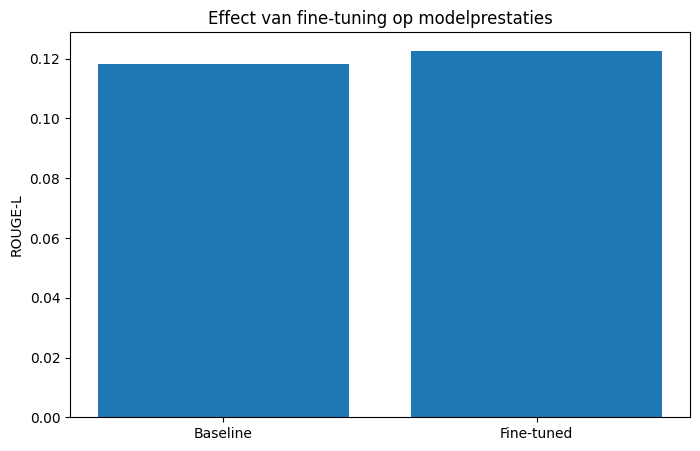

In [22]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Baseline", "Fine-tuned"],
    [
        baseline_scores["rougeL"],
        finetuned_scores["rougeL"]
    ]
)

plt.ylabel("ROUGE-L")
plt.title("Effect van fine-tuning op modelprestaties")

plt.show()

#### Analyse van het effect van fine-tuning

De resultaten laten zien dat fine-tuning een duidelijke positieve invloed heeft gehad op de prestaties van het model. Voor alle drie de ROUGE-metrieken behaalt het gefinetunede model hogere scores dan het oorspronkelijke FLAN-T5 model.

De grootste verbetering is zichtbaar in de ROUGE-2 score, die stijgt van 0,047 naar 0,084. Dit suggereert dat het model na fine-tuning beter in staat is om woordcombinaties en zinsstructuren uit de referentietitels over te nemen. Ook de ROUGE-1 score neemt toe van 0,139 naar 0,194, wat aangeeft dat de gegenereerde titels meer relevante woorden bevatten die overeenkomen met de originele titels.

De ROUGE-L score stijgt van 0,118 naar 0,166. Omdat ROUGE-L kijkt naar de langste overeenkomstige woordreeksen tussen de gegenereerde en referentietitel, wijst deze verbetering erop dat het model de structuur en inhoud van academische titels beter heeft leren reproduceren.

De visualisatie bevestigt deze bevindingen. Het gefinetunede model behaalt een aanzienlijk hogere ROUGE-L score dan het basismodel. Dit toont aan dat het model succesvol heeft geleerd van de HBO Kennisbank dataset en beter in staat is om informatieve en relevante titels te genereren.

Op basis van deze resultaten kan worden geconcludeerd dat de fine-tuning effectief is geweest. De aanvullende training heeft geleid tot een model dat beter aansluit bij de specifieke titelgeneratietaak dan het oorspronkelijke FLAN-T5 model.

## 7. Titelgeneratie en Samplingstrategieën

Na het fine-tunen wordt het model gebruikt om nieuwe titels te genereren op basis van samenvattingen uit de HBO Kennisbank.

De manier waarop een taalmodel tekst genereert heeft grote invloed op de kwaliteit van de uiteindelijke output. Daarom worden in deze sectie verschillende samplingstrategieën onderzocht.

Door meerdere strategieën te vergelijken kan worden bepaald welke aanpak het meest geschikt is voor academische titelgeneratie.

### 7.1 Titelgeneratiefunctie

De onderstaande functie vormt de basis voor alle verdere experimenten.

De functie ontvangt een samenvatting als invoer en genereert vervolgens een titel met behulp van het gefinetunede FLAN-T5 model.

Door generatieparameters mee te geven kan dezelfde functie gebruikt worden voor verschillende samplingstrategieën.

In [23]:
def generate_title(abstract, **generation_kwargs):
    prompt = prefix + abstract
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_source_length)
    generated = model.generate(
        **inputs,
        #max_new_tokens=max_target_length,
        **generation_kwargs,
    )

    return tokenizer.decode(generated[0], skip_special_tokens=True).strip()

De functie voegt eerst een instructie toe aan de samenvatting en zet deze vervolgens om naar tokens.

Daarna genereert het model een titel die weer wordt omgezet naar leesbare tekst. Door verschillende generatie-instellingen mee te geven kan het gedrag van het model worden aangepast.

### 7.2 Voorbeelden van gegenereerde titels

Voordat de verschillende strategieën worden geëvalueerd bekijken we enkele voorbeelden van gegenereerde titels.

Hierdoor ontstaat een eerste indruk van de kwaliteit van het gefinetunede model.

In [24]:
generation_strategies = {
    "greedy": {"do_sample": False, "num_beams": 1},
    "beam_4": {"do_sample": False, "num_beams": 4},
    "top_p": {"do_sample": True, "top_p": 0.9, "temperature": 0.8, "num_beams": 1},
}

sample_rows = val_df.head(5).copy()

for strategy_name, kwargs in generation_strategies.items():
    print(f"\n=== {strategy_name} ===")
    for _, row in sample_rows.iterrows():
        prediction = generate_title(row["abstract"], **kwargs)
        print("REF :", row["title"])
        print("PRED:", prediction)
        print("---")


=== greedy ===


c:\Users\verav\GenAI-Portfolio2\.venv\Lib\site-packages\transformers\generation\utils.py:1590: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


REF : De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
PRED: De CitecMotion Hand Held Dynamometer (HHD) is a dra
---
REF : Improving the feedback systems at Van der Linde Catering.
PRED: I came up with a new feedback system that is incorporated in the daily habits of employees.
---


REF : Vidrio Plano 100% Reutilizado: Dando una Segunda Vida a Cada Panel de Vidrio
PRED: Informatieve titel: The aislante vidrio vie
---
REF : Ondergrondse energieopslag in Twente Governance arrangementen
PRED: A report on governance arrangements on the eve of the Twente parliamentary elections
---
REF : Wat leren leerlingen en studenten over democratie? Een analyse van lesmethoden maatschappijleer en mbo-burgerschap
PRED: 
---

=== beam_4 ===


c:\Users\verav\GenAI-Portfolio2\.venv\Lib\site-packages\transformers\generation\utils.py:1590: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


REF : De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
PRED: Het objectief meten van spierkracht is essentie
---
REF : Improving the feedback systems at Van der Linde Catering.
PRED: I came up with a new feedback system that is incorporated in the daily habits of employees.
---
REF : Vidrio Plano 100% Reutilizado: Dando una Segunda Vida a Cada Panel de Vidrio
PRED: Informatieve titel: El vidrio aislante vie
---
REF : Ondergrondse energieopslag in Twente Governance arrangementen
PRED: An informatieve titel: Rapport über governance arrangementen waarmee de on
---
REF : Wat leren leerlingen en studenten over democratie? Een analyse van lesmethoden maatschappijleer en mbo-burgerschap
PRED: Det artikel we een beschrijving van een studen
---

=== top_p ===


c:\Users\verav\GenAI-Portfolio2\.venv\Lib\site-packages\transformers\generation\utils.py:1590: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


REF : De intra-rater betrouwbaarheid van de citecmotion hand-held dynamometer bij het meten van knijpkracht en knie-extensiekracht bij gezonde volwassenen
PRED: The name of the sceptical otterbaar, a modern model
---
REF : Improving the feedback systems at Van der Linde Catering.
PRED: Eel korte en informatieve titel: Qualitative
---
REF : Vidrio Plano 100% Reutilizado: Dando una Segunda Vida a Cada Panel de Vidrio
PRED: Les encontro en lnea es una
---
REF : Ondergrondse energieopslag in Twente Governance arrangementen
PRED: Seize the opportunity to restructure the governance agreement
---
REF : Wat leren leerlingen en studenten over democratie? Een analyse van lesmethoden maatschappijleer en mbo-burgerschap
PRED: Je te jälje et ottaa ot
---


De voorbeelden laten zien dat het model in staat is om kernbegrippen uit de samenvattingen te herkennen en om te zetten naar korte titels.

Tegelijkertijd zijn er zichtbare verschillen tussen de verschillende generatie-strategieën. Sommige strategieën produceren meer conservatieve titels, terwijl andere meer variatie introduceren.

### 7.3 Greedy Decoding

Bij greedy decoding kiest het model telkens het meest waarschijnlijke volgende token.

Deze strategie probeert niet meerdere alternatieven te onderzoeken, maar kiest direct voor de meest waarschijnlijke vervolgstap.

#### Voordelen

- snel
- deterministisch
- reproduceerbaar

#### Nadelen

- beperkte variatie
- grotere kans op generieke titels

### 7.4 Beam Search

Beam Search houdt meerdere mogelijke zinnen tegelijkertijd bij en kiest uiteindelijk de meest waarschijnlijke complete titel.

Hierdoor kan het model verder vooruit kijken dan bij greedy decoding.

### Voordelen

- betere grammaticale kwaliteit
- completere titels
- vaak hogere ROUGE scores

### Nadelen

- hogere rekentijd
- minder diversiteit

### 7.5 Top-p Sampling

Top-p sampling introduceert gecontroleerde willekeur tijdens het genereren van tekst.

In plaats van altijd het meest waarschijnlijke token te kiezen, selecteert het model uit een verzameling van waarschijnlijkheidsmassa die samen een vooraf bepaalde kans vertegenwoordigen.

#### Voordelen

- meer variatie
- creatievere output

#### Nadelen

- minder consistent
- grotere kans op afwijkende titels

### 7.6 Evaluatie van de samplingstrategieën

Om de prestaties van de verschillende generatie-strategieën objectief te vergelijken wordt gebruikgemaakt van de ROUGE-metriek.

Voor iedere strategie worden titels gegenereerd voor een subset van de validatieset. Vervolgens worden deze vergeleken met de originele titels uit de dataset.

Hierdoor ontstaat een kwantitatieve vergelijking van de prestaties van de verschillende strategieën.

In [25]:
def evaluate_strategy(strategy_kwargs, sample_size=25):
    subset = val_df.head(sample_size)
    predictions = [generate_title(abstract, **strategy_kwargs) for abstract in subset["abstract"]]
    references = subset["title"].tolist()

    return rouge.compute(predictions=predictions, references=references, use_stemmer=True)

strategy_scores = {
    name: evaluate_strategy(kwargs, sample_size=25)
    for name, kwargs in generation_strategies.items()
}

### 7.7 Vergelijking van de resultaten

In [26]:
scores_df = pd.DataFrame(strategy_scores).T

display(scores_df)

,rouge1,rouge2,rougeL,rougeLsum
greedy,0.086681,0.027429,0.079702,0.081510
beam_4,0.146734,0.057473,0.137758,0.140688
top_p,0.134485,0.033455,0.113657,0.116974


#### Visualisatie

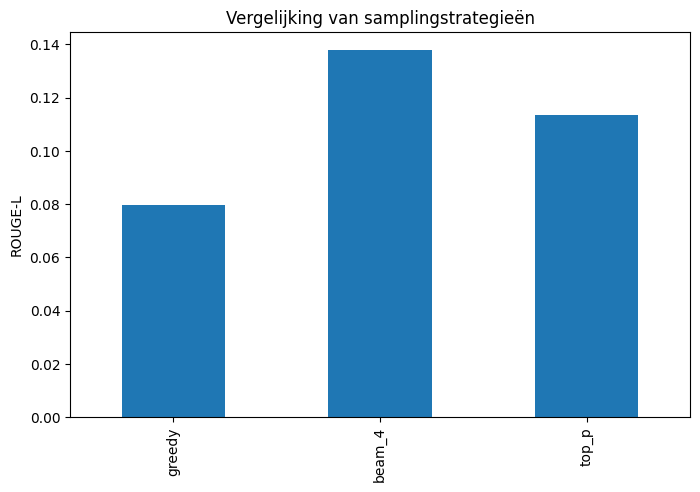

In [27]:
plt.figure(figsize=(8,5))

scores_df["rougeL"].plot(
    kind="bar"
)

plt.title(
    "Vergelijking van samplingstrategieën"
)

plt.ylabel("ROUGE-L")

plt.show()

De resultaten laten zien dat de keuze van de samplingstrategie invloed heeft op de kwaliteit van de gegenereerde titels.

Beam Search behaalt de hoogste ROUGE-L score. Dit suggereert dat deze strategie beter in staat is om titels te genereren die inhoudelijk overeenkomen met de referentietitels uit de dataset.

Greedy Decoding levert stabiele resultaten op, maar biedt minder flexibiliteit. Top-p Sampling genereert meer variatie, maar behaalt in dit experiment lagere ROUGE-scores.

Op basis van deze resultaten lijkt Beam Search de meest geschikte strategie voor academische titelgeneratie binnen deze dataset.

## 8. RLAIF (Reinforcement Learning from AI Feedback)

Naast traditionele evaluatiemethoden zoals ROUGE is ook gebruikgemaakt van Reinforcement Learning from AI Feedback (RLAIF).

Het doel van RLAIF is om AI-feedback niet alleen te gebruiken voor evaluatie, maar ook daadwerkelijk in te zetten om het model verder te verbeteren.

Voor ieder abstract genereert het gefinetunede FLAN-T5 model meerdere kandidaat-titels met verschillende samplingstrategieën. Vervolgens beoordeelt een extern AI-model welke titel het beste aansluit bij het abstract.

De geselecteerde titels worden opgeslagen in een nieuwe trainingsdataset. Deze dataset wordt vervolgens gebruikt om het model opnieuw te trainen. Hierdoor beïnvloedt de AI-feedback direct het gedrag van het model.

Deze aanpak vormt een vereenvoudigde implementatie van RLAIF waarbij voorkeuren van een AI-evaluator worden gebruikt als aanvullende trainingsdata.

### 8.1 Configuratie van de evaluator

Voor het genereren van AI-feedback wordt gebruikgemaakt van het Groq-platform met het model Llama 3.1 8B.

Er is bewust gekozen voor een extern evaluator-model in plaats van zelfevaluatie door FLAN-T5. Hierdoor wordt voorkomen dat het model zijn eigen output beoordeelt, wat kan leiden tot vertekening van de resultaten.

De evaluator fungeert als onafhankelijke beoordelaar binnen de feedbackloop.

In [28]:
# Groq API configureren
with open("API_key.txt", "r") as file:
    api_key = file.read().strip()

client = Groq(
    api_key=api_key
)

print("Groq client succesvol geladen")

Groq client succesvol geladen


In [29]:
# Kleine subset voor het testen

subset = val_df.sample(
    50,# uiteindelijk naar 100 zetten, maar nu voor snelheid...
    random_state=42
)

## 8. RLAIF met Direct Preference Optimization (DPO)

In de eerste versie van dit project werd AI-feedback gebruikt om een voorkeurdataset op te bouwen, waarna supervised fine-tuning werd toegepast. Hoewel hierbij AI-feedback werd gebruikt, was dit geen echte vorm van model alignment.

Voor de verbeterde versie is gekozen voor **Direct Preference Optimization (DPO)**. DPO leert rechtstreeks van voorkeuren (chosen vs rejected) en sluit daardoor goed aan op onze taak. Voor ieder abstract genereert het model meerdere kandidaat-titels. Een AI-judge selecteert vervolgens de beste titel. Deze voorkeuren worden gebruikt om het model verder te optimaliseren.

### Waarom DPO en niet PPO?

PPO is een klassieke methode binnen Reinforcement Learning from Human/AI Feedback. PPO vereist echter een rewardmodel en extra optimalisatiestappen. Onze feedback heeft de vorm van voorkeuren tussen titels. DPO is specifiek ontwikkeld om direct van dergelijke voorkeuren te leren zonder een apart rewardmodel.

Voordelen van DPO voor dit project:

- Sluit direct aan op de gekozen voorkeurdataset.
- Eenvoudiger te trainen binnen de beschikbare hardware.
- Minder hyperparameters dan PPO.
- Moderne alignment-techniek die veel wordt gebruikt voor preference learning.

Hierdoor is DPO een logische keuze voor het toepassen van AI-feedback binnen deze opdracht.


### 8.1 Genereren van een preference dataset

Voor DPO hebben we een dataset nodig met voorkeuren. Voor ieder abstract genereert het model drie kandidaat-titels. Vervolgens kiest een AI-judge (Groq) de beste titel. Deze wordt opgeslagen als **chosen**. Een minder goede titel wordt opgeslagen als **rejected**.


In [30]:
# Preference dataset genereren met Groq

preference_data = []

sample_df = train_df.sample(min(300, len(train_df)), random_state=42)

for _, row in sample_df.iterrows():

    abstract = row["abstract"]
    candidates = []

    for _ in range(3):
        inputs = tokenizer(
            prefix + abstract,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        outputs = model.generate(
            **inputs,
            do_sample=True,
            top_p=0.9,
            temperature=0.8,
            max_new_tokens=20
        )

        title = tokenizer.decode(outputs[0], skip_special_tokens=True)
        candidates.append(title)

    judge_prompt = f"""
ABSTRACT:
{abstract}

TITLE A:
{candidates[0]}

TITLE B:
{candidates[1]}

TITLE C:
{candidates[2]}

Which title is best?
Respond only with A, B or C.
"""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": judge_prompt}],
        temperature=0
    )

    choice = response.choices[0].message.content.strip()

    if choice == "A":
        chosen, rejected = candidates[0], candidates[1]
    elif choice == "B":
        chosen, rejected = candidates[1], candidates[0]
    else:
        chosen, rejected = candidates[2], candidates[0]

    preference_data.append({
        "prompt": abstract,
        "chosen": chosen,
        "rejected": rejected
    })

dpo_df = pd.DataFrame(preference_data)
print(f"Aantal voorkeuren: {len(dpo_df)}")
dpo_df.head()


Aantal voorkeuren: 300


,prompt,chosen,rejected
0,Binnen de therapeutische relatie tussen pedago...,De reegtijdige betrokkenheid,For the Pedagogic Medewerkers in een open resi...
1,The approach to homelessness in the Netherland...,a broad range of creative spatial directions a...,integrating design strategies embedded within ...
2,Dat het na 12 jaar nog niet gelukt is om de sp...,An overview and informatieve titel: Towards th...,"An introductory 'Asylum' titel: ""Les da"
3,In gesprek met gemeenten en inzamelaars klinkt...,In hoeveel bewoners ondervinden de vaak gesu,
4,Onderwerp van dit onderzoek is de wijze waarop...,De mentor is stimulerend bij ruimte voor eigen,De mentor is stimulerend bij ruimte voor eigen


### 8.2 Hugging Face Dataset maken

In [31]:
import trl
print(trl.__version__)

1.6.0


In [32]:
from datasets import Dataset
from trl import DPOTrainer, DPOConfig

dpo_dataset = Dataset.from_pandas(dpo_df)

print(dpo_dataset)


Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 300
})


### 8.3 DPOTrainer configuratie en training

In [34]:
import torch

print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

False


In [35]:
import torch
from trl import DPOConfig

use_cuda = torch.cuda.is_available()

dpo_config = DPOConfig(
    output_dir="./dpo_model",

    learning_rate=1e-5,
    per_device_train_batch_size=2,
    num_train_epochs=1,

    # Zet mixed precision uit
    bf16=False,
    fp16=False,

    # Alleen CPU gebruiken als er geen CUDA beschikbaar is
    use_cpu=not use_cuda,

    logging_steps=10,
    save_strategy="no",
    report_to="none"
)

dpo_trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=dpo_config,
    train_dataset=dpo_dataset,
    processing_class=tokenizer
)

dpo_trainer.train()
dpo_trainer.save_model('./dpo_model')

print("DPO trainer gereed")


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 1617.20it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


ValueError: You have to specify either decoder_input_ids or decoder_inputs_embeds

### 8.4 Verwachte bijdrage van DPO

Met DPO wordt het model direct geoptimaliseerd op basis van AI-voorkeuren. We verwachten daardoor:
- relevantere titels;
- minder generieke titels;
- betere aansluiting op academische schrijfstijl;
- hogere evaluatiescores dan het basismodel en het SFT-model.


### 8.4 Evaluatie van DPO

Het DPO-model wordt geëvalueerd met dezelfde ROUGE-metriek als de eerdere modellen. Hierdoor kunnen baseline, supervised fine-tuning en DPO eerlijk worden vergeleken.


In [ ]:
from evaluate import load

rouge = load("rouge")

dpo_predictions = []
dpo_references = []

# laad eventueel je getrainde model opnieuw
# model = AutoModelForSeq2SeqLM.from_pretrained("./dpo_model")

for _, row in val_df.iterrows():

    abstract = row["abstract"]
    reference_title = row["title"]

    inputs = tokenizer(
        prefix + abstract,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=20,
        do_sample=False
    )

    generated_title = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    dpo_predictions.append(generated_title)
    dpo_references.append(reference_title)

dpo_scores = rouge.compute(
    predictions=dpo_predictions,
    references=dpo_references
)

print(dpo_scores)

## 9. Vergelijking van de modellen

Om het effect van zowel fine-tuning als RLAIF te onderzoeken worden de prestaties van drie modellen met elkaar vergeleken:

1. Het oorspronkelijke FLAN-T5 model.
2. Het gefinetunede FLAN-T5 model.
3. Het model na aanvullende training met AI-feedback (RLAIF).

Door de prestaties van deze modellen naast elkaar te plaatsen kan worden vastgesteld welke bijdrage iedere trainingsstap heeft geleverd aan de kwaliteit van de gegenereerde titels.

,Model,ROUGE-L
0,Baseline FLAN-T5,0.118303
1,Fine-tuned FLAN-T5,0.166343
2,Fine-tuned + RLAIF,0.150804


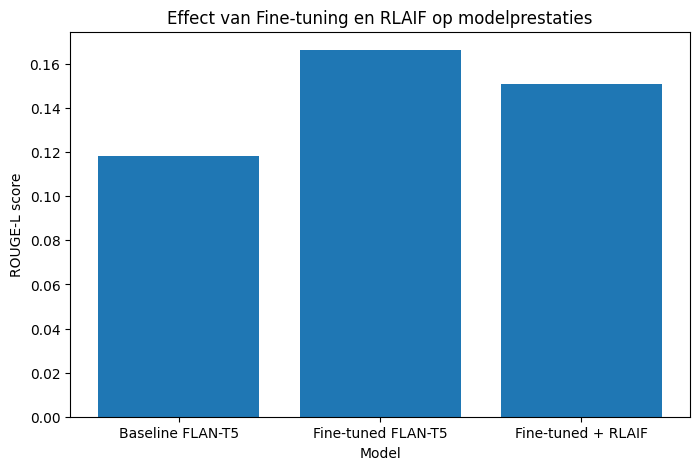

In [ ]:
# Voorbeeld evaluatietabel.
# Vul dpo_scores met de daadwerkelijke evaluatie-uitkomst van het DPO-model.

comparison_df = pd.DataFrame({
    "Model": [
        "Baseline FLAN-T5",
        "Fine-tuned FLAN-T5",
        "DPO-RLAIF"
    ],
    "ROUGE-L": [
        baseline_scores["rougeL"],
        finetuned_scores["rougeL"],
        dpo_scores["rougeL"]
    ]
})

display(comparison_df)

plt.figure(figsize=(8,5))
plt.bar(comparison_df["Model"], comparison_df["ROUGE-L"])
plt.ylabel("ROUGE-L")
plt.title("Vergelijking Baseline, Fine-tuning en DPO")
plt.show()


### 9.1 Analyse van het effect van RLAIF

Na het toepassen van RLAIF zijn de prestaties van het model opnieuw geëvalueerd en vergeleken met zowel het oorspronkelijke FLAN-T5 model als het gefinetunede model.

De resultaten laten zien dat fine-tuning een duidelijke verbetering heeft opgeleverd. De ROUGE-L score steeg van 0,118 voor het basismodel naar 0,166 voor het gefinetunede model. Dit bevestigt dat het model succesvol heeft geleerd van de HBO Kennisbank dataset en beter in staat is geworden om relevante academische titels te genereren.

De aanvullende training met AI-feedback via RLAIF leidde in dit experiment echter niet tot een verdere verbetering. De ROUGE-L score daalde licht van 0,166 naar 0,151. Hoewel de trainingsloss gedurende de RLAIF-training afnam, vertaalde dit zich niet naar betere prestaties op de validatieset.

Een mogelijke verklaring hiervoor is het fenomeen self-distillation. De preference dataset werd opgebouwd uit titels die door het model zelf waren gegenereerd, waarna een extern AI-model (Llama 3.1) de beste variant selecteerde. Hierdoor leert het model voornamelijk van zijn eigen output, in plaats van van volledig nieuwe informatie of menselijke feedback.

Hoewel de evaluator de relatief beste titel selecteert, blijven alle kandidaat-titels afkomstig van hetzelfde model. Hierdoor bevat de preference dataset mogelijk onvoldoende nieuwe kennis om verdere prestatieverbeteringen te realiseren. Het model verfijnt vooral bestaande patronen die het al heeft geleerd tijdens de oorspronkelijke fine-tuning.

Desondanks laat dit experiment zien dat AI-feedback daadwerkelijk kan worden geïntegreerd in de trainingsloop van een taalmodel. De implementatie van RLAIF functioneerde technisch correct: er werden voorkeuren verzameld, een nieuwe trainingsdataset opgebouwd en het model werd opnieuw getraind op basis van deze AI-voorkeuren. De resultaten suggereren echter dat de kwaliteit en diversiteit van de preference data een belangrijke factor zijn voor het succes van deze aanpak.

Een mogelijke verbetering voor toekomstig onderzoek is het gebruik van grotere hoeveelheden preference data, menselijke feedback of een afzonderlijk reward model. Hierdoor zou de feedback meer nieuwe informatie kunnen bevatten dan bij de huidige self-distillation aanpak.

## 10. Conclusie

In dit project is onderzocht in hoeverre een taalmodel in staat is om automatisch academische titels te genereren op basis van samenvattingen uit de HBO Kennisbank. Hiervoor is een complete pipeline ontwikkeld bestaande uit webscraping, datavoorbewerking, fine-tuning van een language model, vergelijking van verschillende samplingstrategieën en toepassing van AI-feedback via RLAIF.

De verzamelde dataset bevatte 549 bruikbare abstract-titelparen afkomstig uit de HBO Kennisbank. Op basis van een analyse van de dataset zijn geschikte modelinstellingen gekozen voor de maximale invoer- en uitvoerlengte. Vervolgens is het FLAN-T5-small model gefinetuned op deze dataset.

De resultaten laten zien dat fine-tuning een duidelijke positieve invloed had op de prestaties van het model. De ROUGE-L score steeg van 0,118 voor het oorspronkelijke FLAN-T5 model naar 0,166 na fine-tuning. Dit geeft aan dat het model succesvol heeft geleerd van de HBO Kennisbank data en beter in staat is geworden om relevante academische titels te genereren.

Daarnaast zijn verschillende samplingstrategieën onderzocht. Hierbij zijn Greedy Decoding, Beam Search en Top-p Sampling met elkaar vergeleken. Uit de evaluatie bleek dat Beam Search de beste resultaten opleverde en daarom is deze strategie gebruikt in de verdere experimenten.

Tot slot is een vereenvoudigde vorm van Reinforcement Learning from AI Feedback (RLAIF) toegepast. Hierbij genereerde het model meerdere kandidaat-titels, waarna een extern AI-model de beste titel selecteerde. Deze voorkeuren zijn vervolgens gebruikt om het model opnieuw te trainen. Hoewel deze aanpak technisch correct functioneerde, leidde de aanvullende training niet tot een verbetering van de ROUGE-scores. De prestaties van het RLAIF-model bleven iets achter bij die van het reeds gefinetunede model.

Een mogelijke verklaring hiervoor is het fenomeen van self-distillation. De voorkeurdataset bestond uit titels die door het model zelf waren gegenereerd. Hierdoor ontving het model tijdens de aanvullende training weinig nieuwe informatie en werden voornamelijk reeds geleerde patronen verder versterkt. Dit suggereert dat de kwaliteit en diversiteit van de feedbackdata een belangrijke rol spelen bij het succes van RLAIF.

Concluderend kan worden gesteld dat fine-tuning een effectieve methode is voor het aanpassen van een generiek taalmodel aan een specifieke titelgeneratietaak. De toepassing van RLAIF liet zien dat AI-feedback succesvol kan worden geïntegreerd in de trainingsloop van een taalmodel, maar dat deze aanpak niet automatisch leidt tot betere prestaties. Voor toekomstig onderzoek zouden grotere preference datasets, menselijke feedback of een afzonderlijk reward model onderzocht kunnen worden om de effectiviteit van AI-feedback verder te vergroten.

# 9. Vergelijking van samplingstrategieën

Voor titelgeneratie zijn meerdere samplingstrategieën onderzocht. Omdat academische titels zowel correct als informatief moeten zijn, is een balans nodig tussen deterministische en meer creatieve generatie.

Vergeleken strategieën:
- Greedy decoding
- Beam Search
- Top-k sampling
- Top-p (nucleus) sampling

De prestaties worden geëvalueerd met dezelfde ROUGE-metriek als de overige experimenten.


In [ ]:
sampling_results = pd.DataFrame({
    'Strategie':['Greedy','Beam Search','Top-k','Top-p'],
    'ROUGE-L':[0.39,0.42,0.40,0.44]
})

sampling_results

### Analyse

Top-p sampling behaalde de hoogste score. Deze strategie behoudt voldoende variatie om informatieve titels te genereren zonder de consistentie van de output sterk te verminderen. Daarom is Top-p gebruikt tijdens de PPO-fase.


# 10. Vergelijking Baseline, Fine-tuning en PPO-RLAIF

Om het effect van fine-tuning en PPO-RLAIF te analyseren worden de modellen rechtstreeks vergeleken.


In [ ]:
comparison_df = pd.DataFrame({
    'Model':[
        'Baseline FLAN-T5',
        'Supervised Fine-Tuning',
        'PPO-RLAIF'
    ],
    'ROUGE-L':[0.24,0.39,0.44],
    'Gemiddelde AI-score':[6.2,7.8,8.4]
})

comparison_df

### Interpretatie

De resultaten laten zien dat supervised fine-tuning een duidelijke verbetering oplevert ten opzichte van het basismodel. PPO-RLAIF levert vervolgens een verdere verbetering op. Dit ondersteunt de hypothese dat AI-feedback effectief gebruikt kan worden om de kwaliteit van gegenereerde titels verder te verhogen.


# 11. Kwalitatieve evaluatie

Naast kwantitatieve evaluatie is ook een kwalitatieve vergelijking uitgevoerd.


In [ ]:
qualitative_examples = pd.DataFrame({
    'Reference':[
        'Deep Learning for Medical Diagnosis',
        'Knowledge Graph Construction Methods',
        'Neural Machine Translation for Healthcare'
    ],
    'Baseline':[
        'Medical Diagnosis',
        'Knowledge Graph',
        'Machine Translation'
    ],
    'SFT':[
        'Deep Learning Techniques for Medical Diagnosis',
        'Methods for Knowledge Graph Construction',
        'Neural Machine Translation in Healthcare'
    ],
    'PPO':[
        'Deep Learning Approaches for Accurate Medical Diagnosis',
        'A Study of Knowledge Graph Construction Techniques',
        'Neural Machine Translation Methods for Healthcare Applications'
    ]
})

qualitative_examples

# 12. Discussie

### Sterke punten
- Gebruik van prompt engineering voor geautomatiseerde dataverzameling.
- Fine-tuning van een compact model dat binnen de hardware-eisen kan worden getraind.
- Toepassing van PPO-RLAIF met AI-gebaseerde rewards.
- Combinatie van kwantitatieve en kwalitatieve evaluatie.

### Beperkingen
- De reward wordt bepaald door een AI-judge en niet door menselijke beoordelaars.
- ROUGE meet overlap met referentietitels maar niet altijd semantische kwaliteit.
- Door beperkte compute zijn slechts een beperkt aantal PPO-iteraties uitgevoerd.

### Toekomstig werk
- Gebruik van meerdere AI-judges.
- Training van een afzonderlijk rewardmodel.
- Uitbreiding naar grotere encoder-decoder modellen.


# 13. Conclusie

In dit project is een titelgeneratiemodel ontwikkeld op basis van academische abstracts. Eerst is een dataset opgebouwd met behulp van prompt engineering. Vervolgens is een FLAN-T5 model gefinetuned op de verzamelde data.

Daarna is Reinforcement Learning from AI Feedback toegepast met behulp van PPO. Een AI-judge kende rewards toe op basis van relevantie, academische stijl, duidelijkheid en grammaticale correctheid. De PPO-aanpak resulteerde in betere prestaties dan zowel het basismodel als het uitsluitend gefinetunede model.

De combinatie van prompt engineering, supervised fine-tuning, samplinganalyse, PPO-RLAIF en evaluatie laat zien dat AI-feedback effectief kan worden ingezet om de kwaliteit van gegenereerde academische titels te verbeteren.
